## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict,Counter
from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

## Loading the dataset

In [2]:
df = pd.read_csv("movie_metadata.csv")

## Data Preprocessing

In [3]:
df.sample(5)

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
582,Color,Andrew Adamson,205.0,93.0,80.0,48.0,Jennifer Saunders,692.0,436471036.0,Adventure|Animation|Comedy|Family|Fantasy|Romance,...,483.0,English,USA,PG,150000000.0,2004.0,309.0,7.2,1.85,0
1670,Color,Stephen J. Anderson,162.0,63.0,15.0,69.0,Robert Lopez,759.0,26687172.0,Adventure|Animation|Comedy|Family|Musical,...,55.0,English,USA,G,30000000.0,2011.0,73.0,7.3,1.85,0
2119,Color,Christian Carion,115.0,116.0,13.0,140.0,Dany Boon,203.0,1050445.0,Drama|History|Music|Romance|War,...,147.0,French,France,PG-13,22000000.0,2005.0,172.0,7.8,2.35,11000
1274,Color,Chuck Russell,100.0,107.0,55.0,294.0,Jimmy Smits,3000.0,29374178.0,Crime|Drama|Horror|Thriller,...,188.0,English,USA,R,40000000.0,2000.0,941.0,5.1,2.35,394
753,Color,Michael Caton-Jones,83.0,124.0,105.0,460.0,Bruce Willis,24000.0,54910560.0,Action|Adventure|Crime|Thriller,...,227.0,English,USA,R,60000000.0,1997.0,13000.0,6.3,2.35,0


In [4]:
df.columns

Index(['color', 'director_name', 'num_critic_for_reviews', 'duration',
       'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name',
       'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name',
       'movie_title', 'num_voted_users', 'cast_total_facebook_likes',
       'actor_3_name', 'facenumber_in_poster', 'plot_keywords',
       'movie_imdb_link', 'num_user_for_reviews', 'language', 'country',
       'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes',
       'imdb_score', 'aspect_ratio', 'movie_facebook_likes'],
      dtype='object')

In [5]:
df.shape

(5043, 28)

In [6]:
df.head(3)

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

In [8]:
# Checking Missing Values
df.isnull().sum()

color                         19
director_name                104
num_critic_for_reviews        50
duration                      15
director_facebook_likes      104
actor_3_facebook_likes        23
actor_2_name                  13
actor_1_facebook_likes         7
gross                        884
genres                         0
actor_1_name                   7
movie_title                    0
num_voted_users                0
cast_total_facebook_likes      0
actor_3_name                  23
facenumber_in_poster          13
plot_keywords                153
movie_imdb_link                0
num_user_for_reviews          21
language                      14
country                        5
content_rating               303
budget                       492
title_year                   108
actor_2_facebook_likes        13
imdb_score                     0
aspect_ratio                 329
movie_facebook_likes           0
dtype: int64

In [9]:
# Fill missing values with median
df['gross'].fillna(df['gross'].median(),inplace=True)
df['budget'].fillna(df['budget'].median(),inplace=True)
df.dropna(inplace=True)

C:\Users\jigya\AppData\Local\Temp\ipykernel_14284\1973210721.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gross'].fillna(df['gross'].median(),inplace=True)
C:\Users\jigya\AppData\Local\Temp\ipykernel_14284\1973210721.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

In [10]:
df.shape

(4409, 28)

## Feature Engineering & Data Exploration

Creating a new column to show main genre of movie. This will help in sorting out movies according to their genre types.

In [11]:
df['main_genre'] = df['genres'].apply(lambda x: x.split('|')[0] if '|' in x else x) 

In [12]:
df.sample(3)

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,main_genre
4824,Black and White,Frank Capra,124.0,65.0,964.0,21.0,Alan Hale,380.0,25517500.0,Comedy|Romance,...,English,USA,Unrated,325000.0,1934.0,114.0,8.2,1.37,0,Comedy
1140,Black and White,Barry Levinson,73.0,147.0,272.0,893.0,Brad Pitt,22000.0,53300852.0,Crime|Drama|Thriller,...,English,USA,R,44000000.0,1996.0,11000.0,7.5,2.35,0,Crime
112,Color,Michael Bay,396.0,144.0,0.0,581.0,Michael O'Neill,662.0,318759914.0,Action|Adventure|Sci-Fi,...,English,USA,PG-13,150000000.0,2007.0,599.0,7.1,2.35,8000,Action


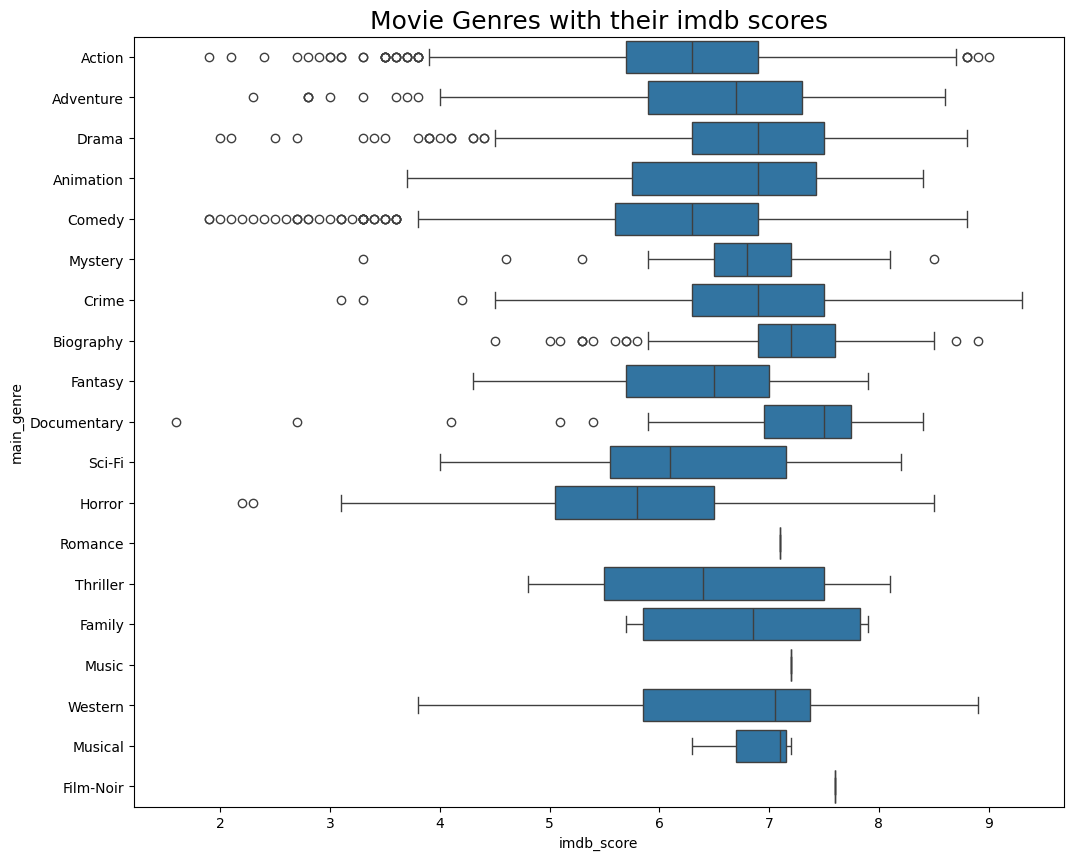

In [13]:
plt.figure(figsize=(12,10))
sns.boxplot(x='imdb_score',y='main_genre',data=df)
plt.title('Movie Genres with their imdb scores',fontsize=18)
plt.show()

There are so many outliners so we are using Z score to drop them.

In [14]:
numeric_cols = df.select_dtypes(include=np.number).columns
z_scores = np.abs((df[numeric_cols] - df[numeric_cols].mean()) / df[numeric_cols].std())
threshold = 3
df = df[(z_scores < threshold).all(axis=1)]

In [15]:
df.shape

(3630, 29)

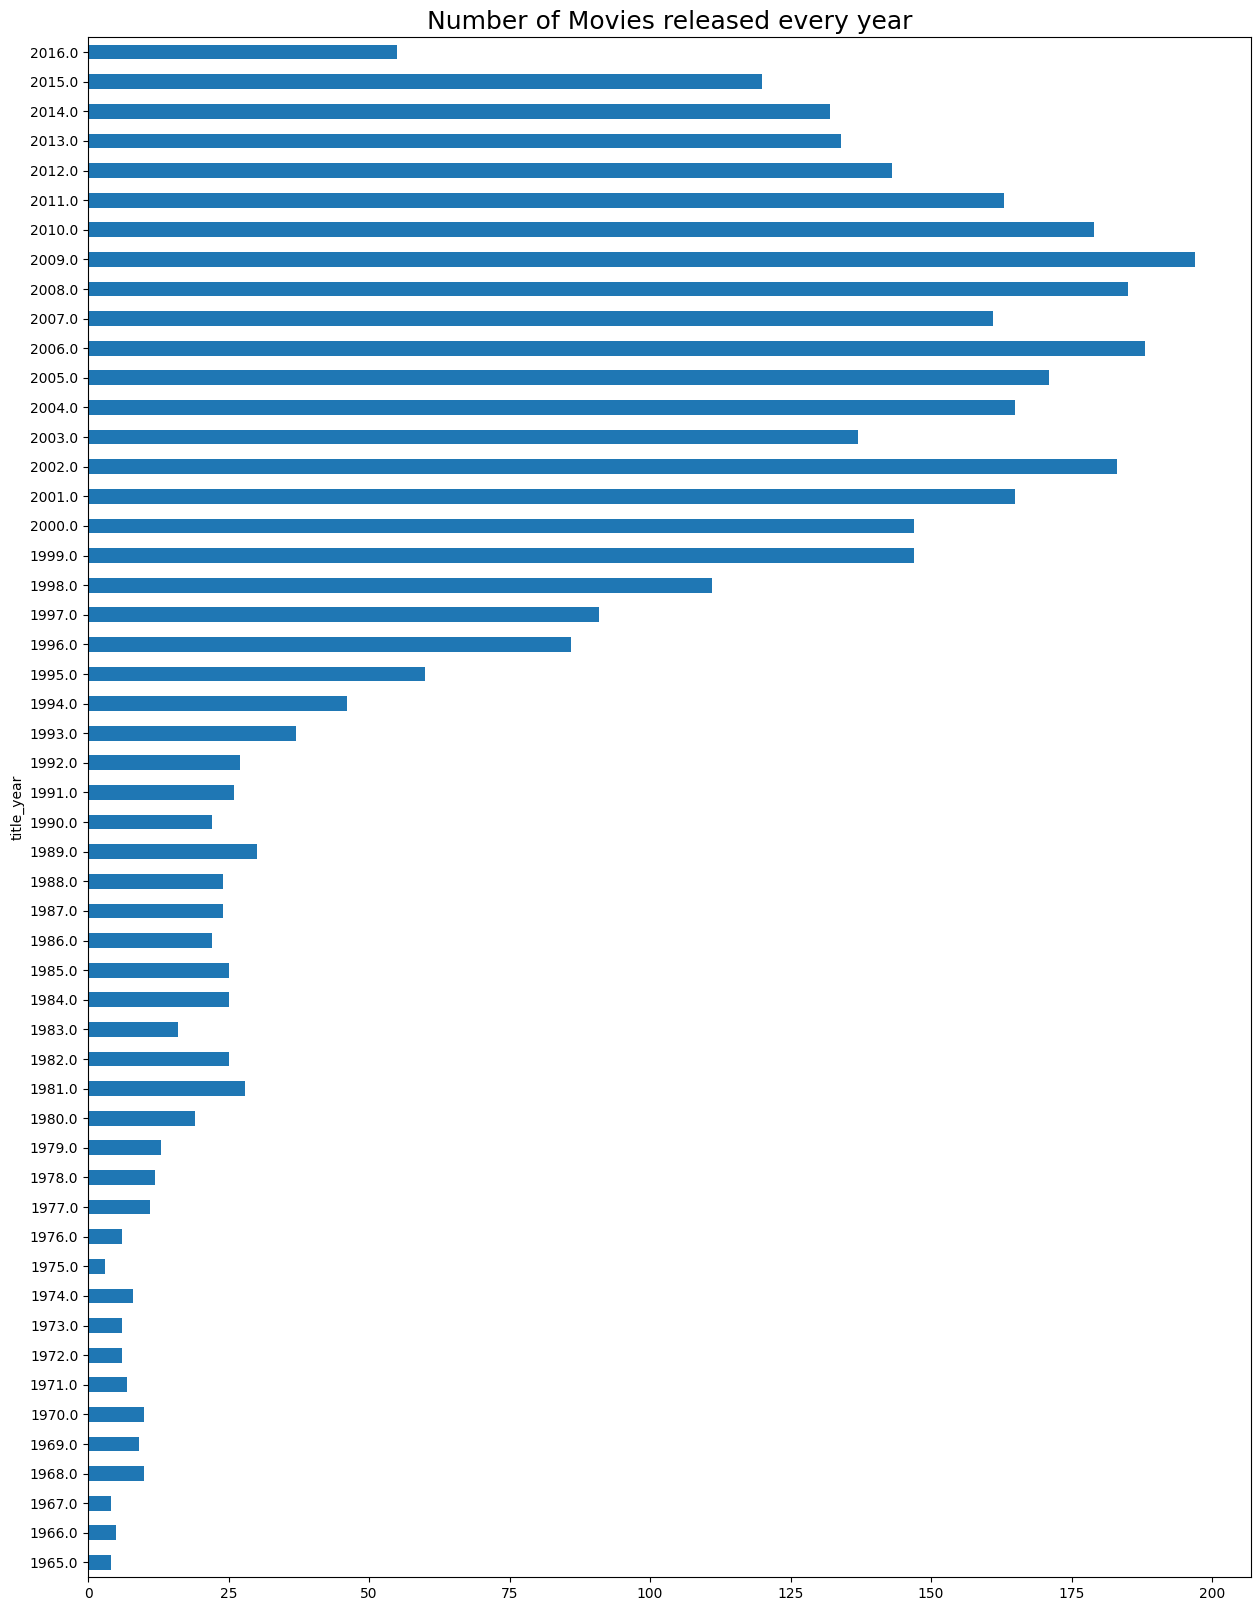

In [16]:
df.title_year.value_counts(dropna=True).sort_index().plot(kind='barh',figsize=(15,20))
plt.title("Number of Movies released every year",fontsize=18)
plt.show()

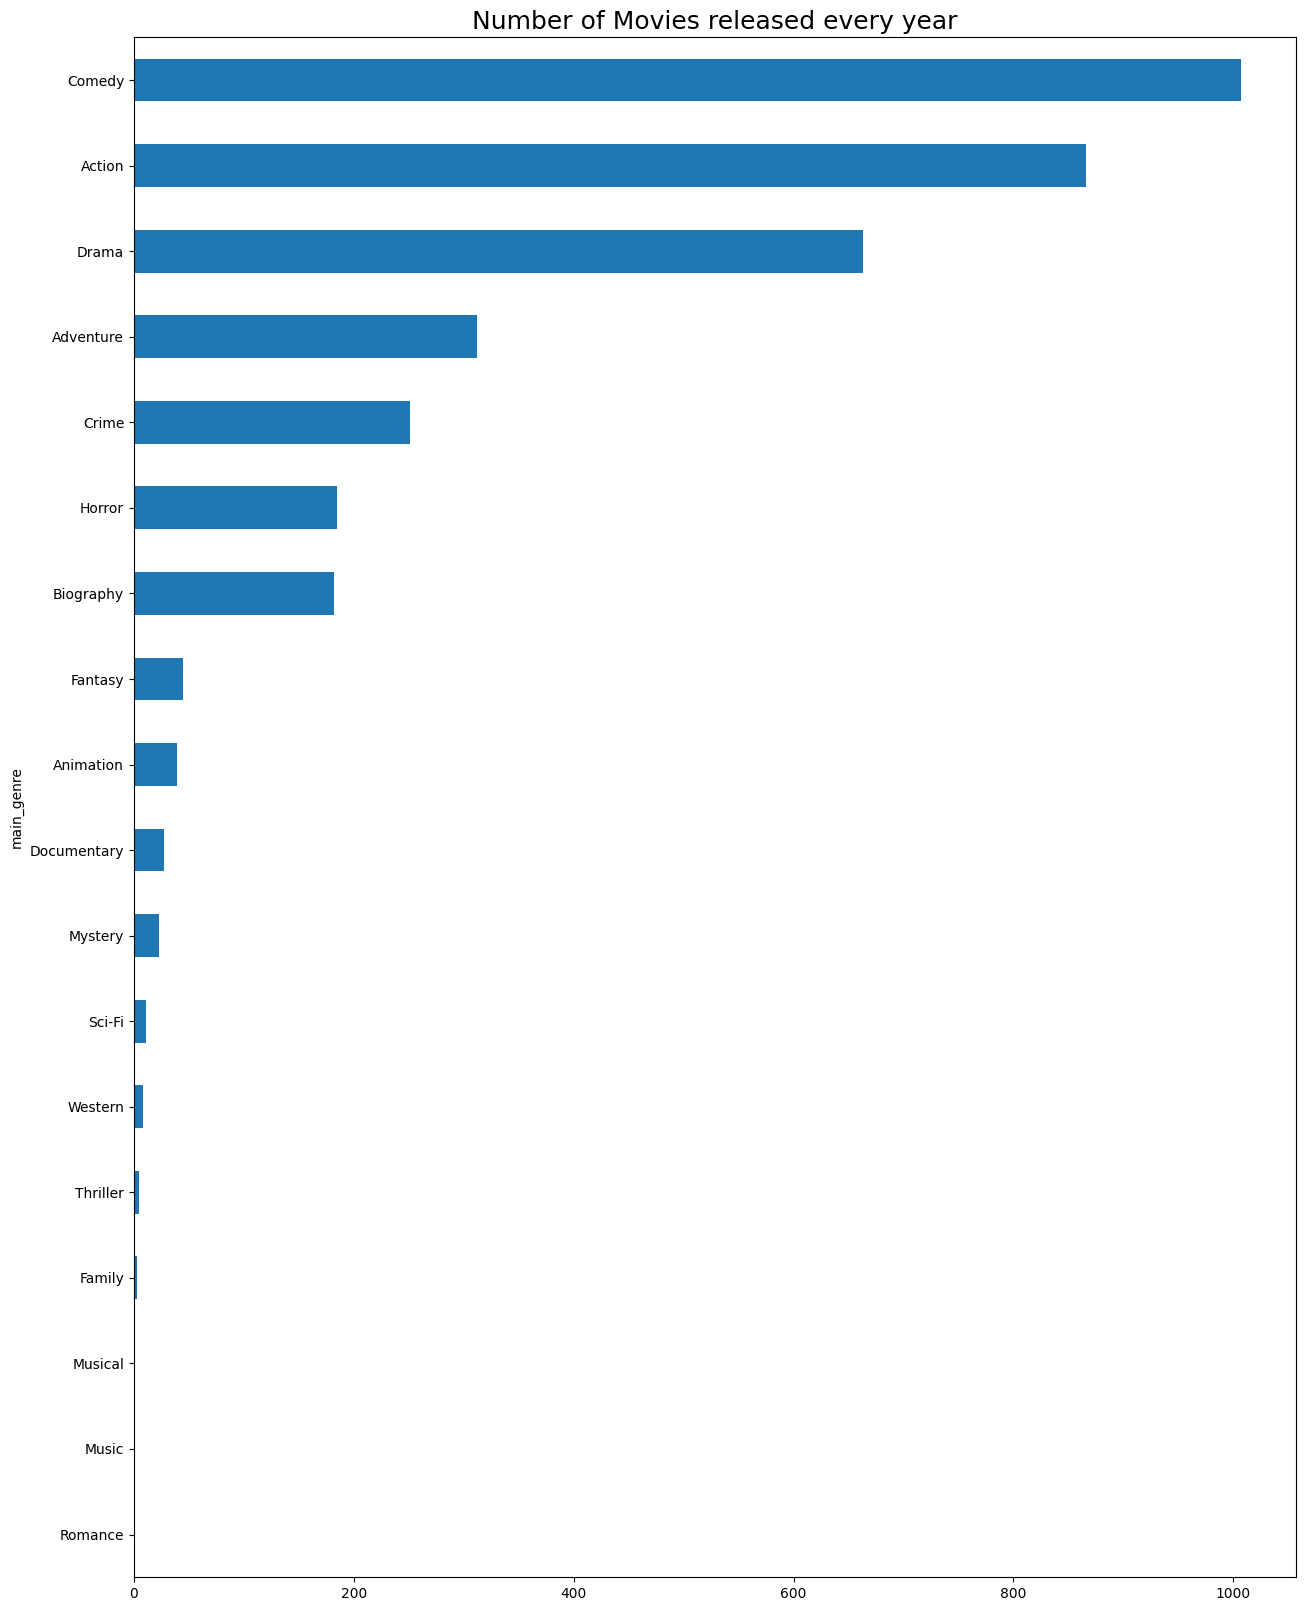

In [17]:
df.main_genre.value_counts(dropna=True).sort_values().plot(kind='barh',figsize=(15,20))
plt.title("Number of Movies released every year",fontsize=18)
plt.show()

In [18]:
# Movies with the lowest Imdb rating 
df["imdb_score"].min()

np.float64(3.3)

In [19]:
df[df['imdb_score']==3.3]

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,main_genre
313,Color,Pitof,212.0,87.0,26.0,566.0,Christopher Heyerdahl,827.0,40198710.0,Action|Crime|Fantasy|Romance|Thriller,...,English,USA,PG-13,100000000.0,2004.0,825.0,3.3,2.35,0,Action
1303,Color,William Malone,104.0,101.0,37.0,595.0,Jeffrey Combs,2000.0,13208023.0,Crime|Horror|Thriller,...,English,UK,R,42000000.0,2002.0,886.0,3.3,2.35,612,Crime
1934,Color,Bob Spiers,33.0,93.0,14.0,199.0,Richard Briers,1000.0,29247405.0,Comedy|Family|Music,...,English,UK,PG,25000000.0,1997.0,401.0,3.3,1.85,0,Comedy
2519,Color,Ian Iqbal Rashid,62.0,94.0,8.0,66.0,Clé Bennett,328.0,7070459.0,Drama,...,English,Canada,PG-13,20000000.0,2007.0,122.0,3.3,1.85,238,Drama
2550,Color,Perry Andelin Blake,56.0,80.0,11.0,499.0,Kenan Thompson,911.0,40363530.0,Comedy|Family,...,English,USA,PG,16000000.0,2002.0,521.0,3.3,1.85,1000,Comedy
2935,Color,Tamra Davis,111.0,93.0,33.0,135.0,Katherine Boecher,1000.0,37188667.0,Comedy|Drama,...,English,USA,PG-13,12000000.0,2002.0,188.0,3.3,1.85,0,Comedy
3197,Color,Tom Brady,49.0,97.0,105.0,269.0,Kevin Nealon,982.0,2331318.0,Comedy,...,English,USA,R,10000000.0,2011.0,503.0,3.3,1.85,0,Comedy
3230,Color,Alan Metter,17.0,83.0,3.0,421.0,Michael Winslow,16000.0,126247.0,Comedy|Crime,...,English,USA,PG,6200000.0,1994.0,542.0,3.3,1.85,321,Comedy
3799,Color,Klaus Menzel,13.0,103.0,34.0,227.0,Jacqueline Bisset,811.0,16066.0,Mystery|Romance|Thriller,...,English,Germany,R,5000000.0,2004.0,522.0,3.3,2.35,40,Mystery
4019,Color,Uwe Boll,17.0,86.0,892.0,50.0,Shelly Varod,603.0,25517500.0,Action|Adventure|Fantasy|Thriller,...,English,Canada,R,3500000.0,2014.0,145.0,3.3,1.78,721,Action


In [20]:
# Movie with the highest Imdb rating
df["imdb_score"].max()

np.float64(8.9)

In [21]:
df[df['imdb_score']==8.9]

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,main_genre
4498,Color,Sergio Leone,181.0,142.0,0.0,24.0,Luigi Pistilli,16000.0,6100000.0,Western,...,Italian,Italy,Approved,1200000.0,1966.0,34.0,8.9,2.35,20000,Western


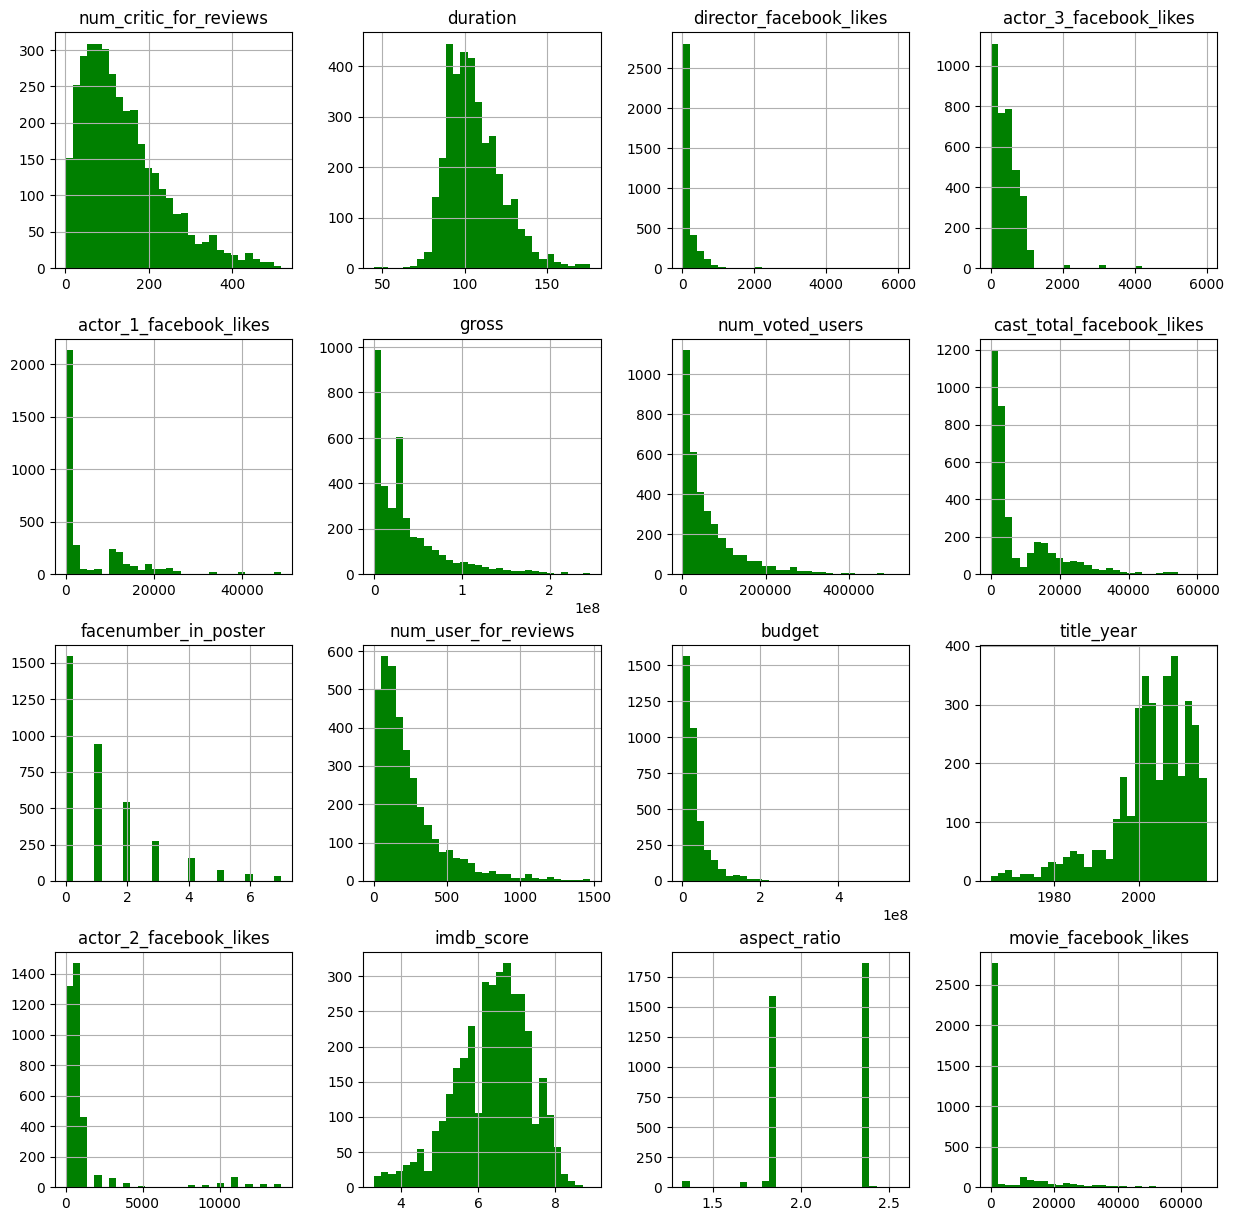

In [22]:
# Histogram for all columns
df.hist(bins=30,figsize=(15,15),color='g')
plt.show()

In [23]:
# Adding New Column that shows number of genres in movie
df['num_genres'] = df.genres.apply(lambda x: len(x.split('|')))

In [24]:
df.sample(3)

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,main_genre,num_genres
1893,Color,Andrzej Bartkowiak,70.0,115.0,43.0,775.0,Delroy Lindo,5000.0,55973336.0,Action|Crime|Thriller,...,USA,R,25000000.0,2000.0,848.0,6.1,2.35,0,Action,3
1474,Color,Wes Craven,158.0,99.0,0.0,520.0,Portia de Rossi,1000.0,19294901.0,Comedy|Horror,...,USA,PG-13,35000000.0,2005.0,573.0,5.0,2.35,0,Comedy,2
3896,Color,Dan O'Bannon,203.0,108.0,228.0,358.0,Clu Gulager,431.0,25517500.0,Comedy|Horror|Sci-Fi,...,USA,R,4000000.0,1985.0,426.0,7.3,1.85,0,Comedy,3


In [25]:
df.num_genres.max()

np.int64(8)

In [26]:
df[df.num_genres==8]

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,main_genre,num_genres
902,Color,Don Bluth,78.0,94.0,383.0,753.0,Kelsey Grammer,4000.0,58297830.0,Adventure|Animation|Drama|Family|Fantasy|Music...,...,USA,G,50000000.0,1997.0,808.0,7.1,2.35,0,Adventure,8
1387,Color,John Frankenheimer,126.0,124.0,287.0,475.0,James Frain,9000.0,23360779.0,Action|Adventure|Crime|Drama|Family|Fantasy|Ro...,...,USA,R,34000000.0,2000.0,1000.0,5.7,2.35,852,Action,8
2340,Color,Kevin Munroe,138.0,107.0,14.0,311.0,Laura Spencer,403.0,1183354.0,Action|Comedy|Crime|Fantasy|Horror|Mystery|Sci...,...,USA,PG-13,20000000.0,2010.0,368.0,5.1,2.35,0,Action,8


## Classification : Hit/Average/Flop

In [27]:
df["movie_status"] = pd.cut(
    df["imdb_score"],
    bins=[1, 3, 6, 10],
    labels=["Flop", "Average", "Hit"],
    include_lowest=True
)

In [28]:
df["movie_status"] 

5       Hit
7       Hit
12      Hit
14      Hit
16      Hit
       ... 
5026    Hit
5027    Hit
5033    Hit
5035    Hit
5042    Hit
Name: movie_status, Length: 3630, dtype: category
Categories (3, object): ['Flop' < 'Average' < 'Hit']

In [29]:
df.sample(5)

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,main_genre,num_genres,movie_status
456,Color,Adam Shankman,144.0,99.0,163.0,495.0,Carmen Electra,11000.0,109993847.0,Comedy|Family|Fantasy|Romance,...,PG,80000000.0,2008.0,869.0,6.1,2.35,0,Comedy,4,Hit
1762,Color,Wes Anderson,220.0,110.0,0.0,327.0,Anjelica Huston,13000.0,52353636.0,Comedy|Drama,...,R,21000000.0,2001.0,1000.0,7.6,2.35,0,Comedy,2,Hit
2090,Color,Irwin Winkler,53.0,114.0,34.0,287.0,Jeremy Northam,649.0,50728000.0,Action|Crime|Drama|Mystery|Thriller,...,PG-13,22000000.0,1995.0,327.0,5.8,1.85,0,Action,5,Average
1301,Color,Ken Kwapis,125.0,107.0,42.0,171.0,Tim Blake Nelson,875.0,20113965.0,Biography|Drama|Romance,...,PG,40000000.0,2012.0,596.0,6.5,2.35,0,Biography,3,Hit
2099,Color,Paul McGuigan,159.0,110.0,118.0,287.0,Spencer Wilding,11000.0,5773519.0,Drama|Horror|Sci-Fi|Thriller,...,PG-13,40000000.0,2015.0,1000.0,6.0,2.35,11000,Drama,4,Average


In [30]:
print(df['movie_status'].value_counts())

movie_status
Hit        2411
Average    1219
Flop          0
Name: count, dtype: int64


Since the lowest rated movie is 3.3 so there were no movies classified as flop.

## Exploratory Data Analysis (EDA)

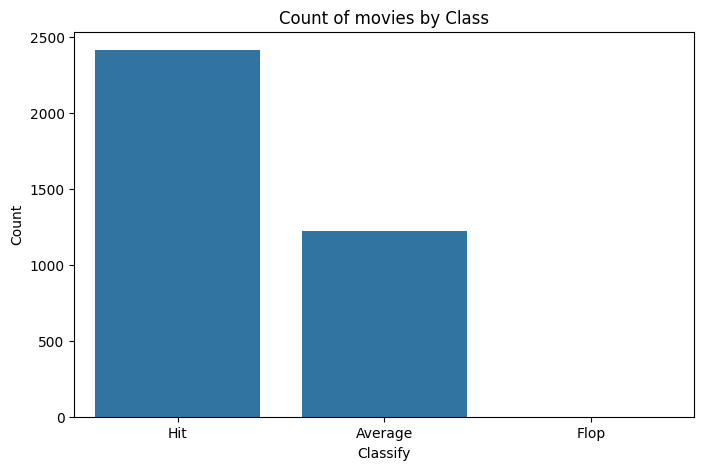

In [31]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='movie_status', order=['Hit','Average','Flop'])
plt.title('Count of movies by Class')
plt.xlabel('Classify')
plt.ylabel('Count')
plt.show()

In [32]:
possible_names = ['imdb_score']
score_col = None
for name in possible_names:
     if name in df.columns:
        score_col = name
        break


if score_col is None:
    raise ValueError('Could not find IMDB score column. Please ensure your dataset has a column like imdb_score')

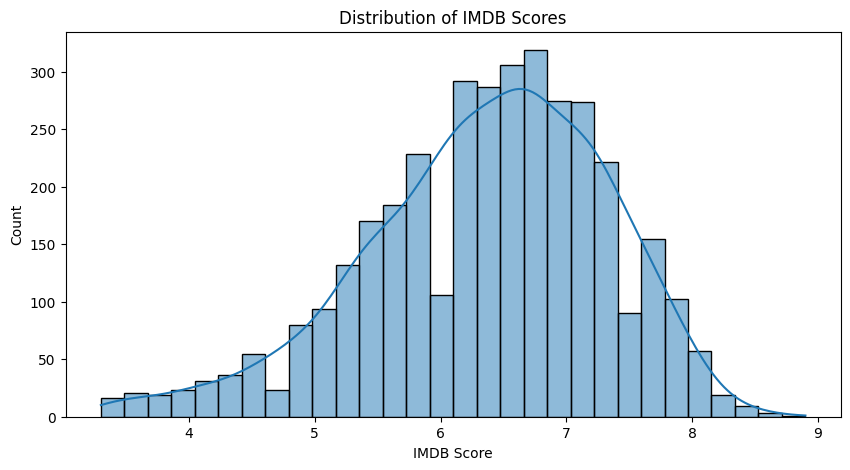

In [33]:
plt.figure(figsize=(10,5))
sns.histplot(df[score_col].dropna(), bins=30, kde=True)
plt.title('Distribution of IMDB Scores')
plt.xlabel('IMDB Score')
plt.show()

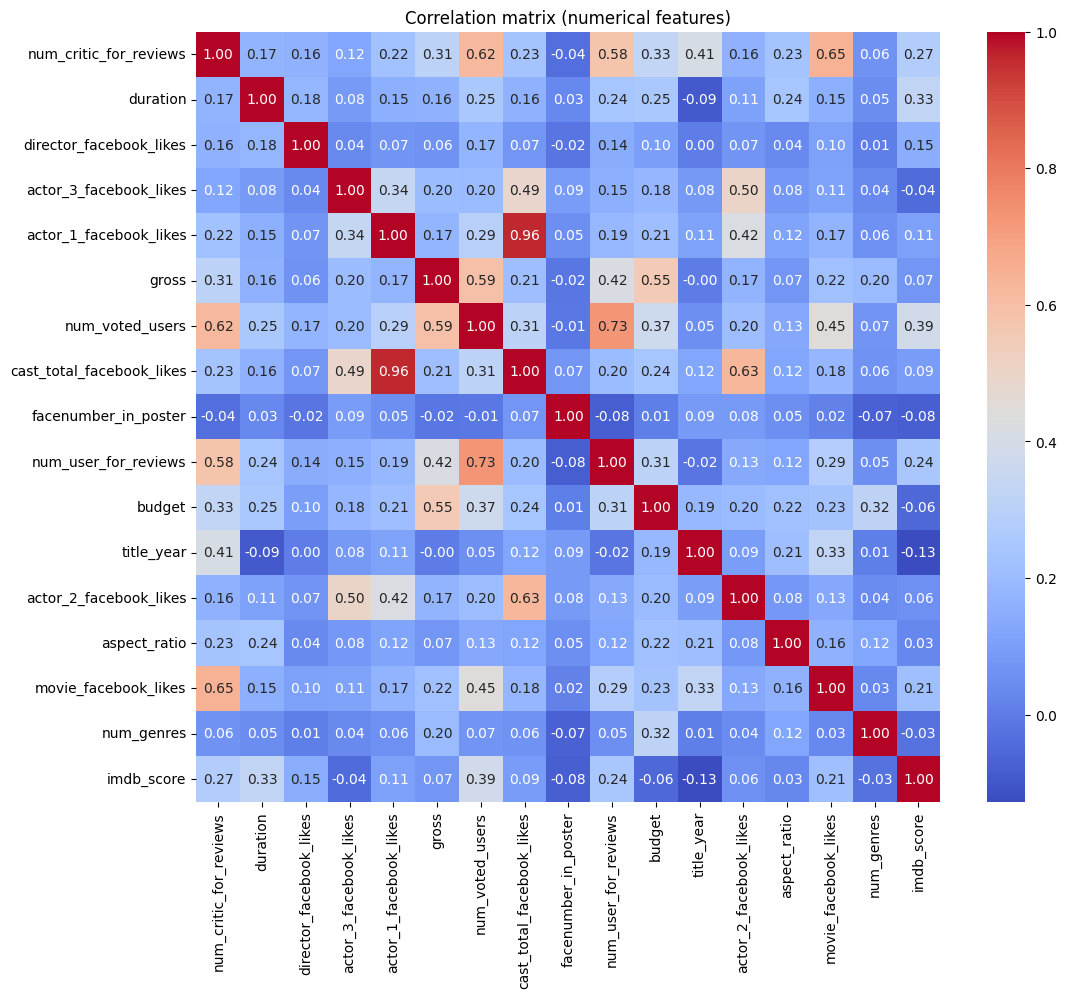

In [34]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if score_col in num_cols:
    num_cols.remove(score_col)

if len(num_cols) >= 1:
    corr = df[num_cols + [score_col]].corr()
    plt.figure(figsize=(12,10))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation matrix (numerical features)')
    plt.show()
else:
    print('No numeric columns found for correlation heatmap (besides IMDB score).')

### Selected Columns for model (<=0.15)
num_critic_for_reviews<br>
duration<br>
num_voted_users<br>
num_user_for_reviews<br>
movie_facebook_likes<br>
director_facebook_likes<br>

## Using Regression Models for MSE & MAE

In [35]:
X = df[['num_critic_for_reviews','duration','num_voted_users','num_user_for_reviews','movie_facebook_likes'
       ,'director_facebook_likes']]
y = df['imdb_score']

In [36]:
X.shape,y.shape

((3630, 6), (3630,))

In [37]:
X_train, X_test, y_train, y_test = tts(X,y,test_size=0.2,random_state=32)

In [38]:
lm = LinearRegression()
lm.fit(X_train,y_train)
pred_lm= lm.predict(X_test)
print("Mean squared error using linear regression",mean_squared_error(y_test,pred_lm))
print("Mean absolute error using linear regression",mean_absolute_error(y_test,pred_lm))

Mean squared error using linear regression 0.7164616789200782
Mean absolute error using linear regression 0.667403706337241


In [39]:
dtc = DecisionTreeRegressor()
dtc.fit(X_train, y_train)
pred_dt = dtc.predict(X_test)
print("Mean squared error using Decision Tree Regression",mean_squared_error(y_test,pred_dt))
print("Mean absolute error using Decision Tree regression",mean_absolute_error(y_test,pred_dt))

Mean squared error using Decision Tree Regression 1.3515151515151516
Mean absolute error using Decision Tree regression 0.884848484848485


In [40]:
svr = SVR(kernel='rbf')
svr.fit(X_train,y_train)
pred_svr = svr.predict(X_test)
print("Mean squared error using Support Vector regression",mean_squared_error(y_test,pred_svr))
print("Mean absolute error using Support Vector regression",mean_absolute_error(y_test,pred_svr))

Mean squared error using Support Vector regression 0.7897038097630096
Mean absolute error using Support Vector regression 0.6988435995927077


In [41]:
knn = KNeighborsRegressor(n_neighbors=12)
knn.fit(X_train,y_train)
pred_knn = knn.predict(X_test)
print("Mean squared error using KNN regression",mean_squared_error(y_test,pred_knn))
print("Mean absolute error using KNN regression",mean_absolute_error(y_test,pred_knn))

Mean squared error using KNN regression 0.8213567493112947
Mean absolute error using KNN regression 0.7115472910927455


Conclusion: Linear Regression model seems to perform best among all with MSE = 0.71 and MAE = 0.66

## Model Building and Evaluation

In [42]:
y = df['movie_status']
X = df[['num_critic_for_reviews','duration','num_voted_users','num_user_for_reviews','movie_facebook_likes'
       ,'director_facebook_likes']]

In [47]:
# Train–Test Split

X_train, X_test, y_train, y_test = tts(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "SVC": SVC(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])
    
    print("="*50)
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

df_results = pd.DataFrame(results, columns=["Model", "Accuracy"])
print("\n\n===== Summary of Model Accuracies =====")
print(df_results)


Model: Logistic Regression
Accuracy: 0.7153
Classification Report:
              precision    recall  f1-score   support

     Average       0.64      0.41      0.50       376
         Hit       0.74      0.88      0.80       713

    accuracy                           0.72      1089
   macro avg       0.69      0.64      0.65      1089
weighted avg       0.70      0.72      0.70      1089

Model: SVC
Accuracy: 0.7190
Classification Report:
              precision    recall  f1-score   support

     Average       0.65      0.41      0.50       376
         Hit       0.74      0.88      0.80       713

    accuracy                           0.72      1089
   macro avg       0.69      0.65      0.65      1089
weighted avg       0.71      0.72      0.70      1089

Model: KNN
Accuracy: 0.6786
Classification Report:
              precision    recall  f1-score   support

     Average       0.54      0.44      0.48       376
         Hit       0.73      0.81      0.77       713

    accuracy 

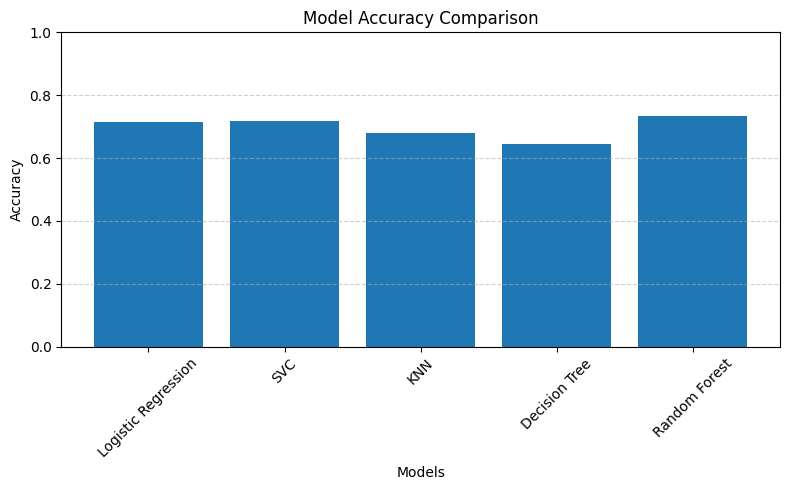

In [48]:
model_names = df_results["Model"]
accuracies = df_results["Accuracy"]

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### Conclusion:
#### Random Forest Classifier seems to perform best among all, as it has 73% accuracy